# Uurimuslik andmeanalüüs ja pideva muutuja ennustamine

## Sisukord

* [Visualiseerimine teegiga Seaborn](#visu)
* [Ülesanne 10.1](#10_1)
* [Korrelatsioonimaatriks](#kor)
* [Lineaarregressioon](#lin)
* [Determinatsioonikordaja R2 mudeli hindamiseks](#r2)
* [Polünomiaalregressioon](#poly)
* [Otsustuspuu regressioon](#puu)
* [Ülesanne 10.2](#10_2)

Põhineb S.Raschka *Python Machine Learnig* raamatu 
[peatükil 10](https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch10) ([*MIT litsents*](https://github.com/rasbt/python-machine-learning-book/blob/master/LICENSE.txt)).

<a id='visu'></a>

## Visualiseerimine teegiga *Seaborn*

Uurimusliku andmeanalüüsi osas vaatleme erinevaid võimalusi muutujatevaheliste seoste (korrelatsioonide) uurimiseks: väikesed hajuvusgraafikud(scatterplot) üle atribuutide paaride ja korrelatsioonimaatriks. Teek [seaborn](https://seaborn.pydata.org/) pakub matplotlib teegi peale ehitatud lisavõimalusi andmete visualiseerimiseks.

In [1]:
import numpy as np
import pandas as pd


from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
housing_data = fetch_california_housing()
X = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
y = housing_data.target
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
print(housing_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
X_target = X.assign(MEDV=y)

Teek *Seaborn* pakub funktsioone küllaltki keerukate diagrammide lihtsaks koostamiseks. Selle diagrammitüüp `pairplot` võimaldab kirjeldada $n$ atribuudi paaritisi seoseid $n \times n$ väikese hajusgraafikuga (*scatterplot*), mis on paigutatud tabelisse. Tabeli lahtris rea*i* ja veeru *j* asub atribuutide *i* ja *j* seost kirjeldav hajusgraafik. Erandiks on peadiagonaal, sest atribuudi hajusgraafik iseendaga on alati sirge , mis uut informatsiooni ei anna. Peadiagonaalil on iga atribuudi väärtuste jaotust kirjeldavad histogrammid. Selline graafik vastab E. Tufte kirjeldatud väikeste korduste (*small multiples*) andmevisualiseerimise mustrile.

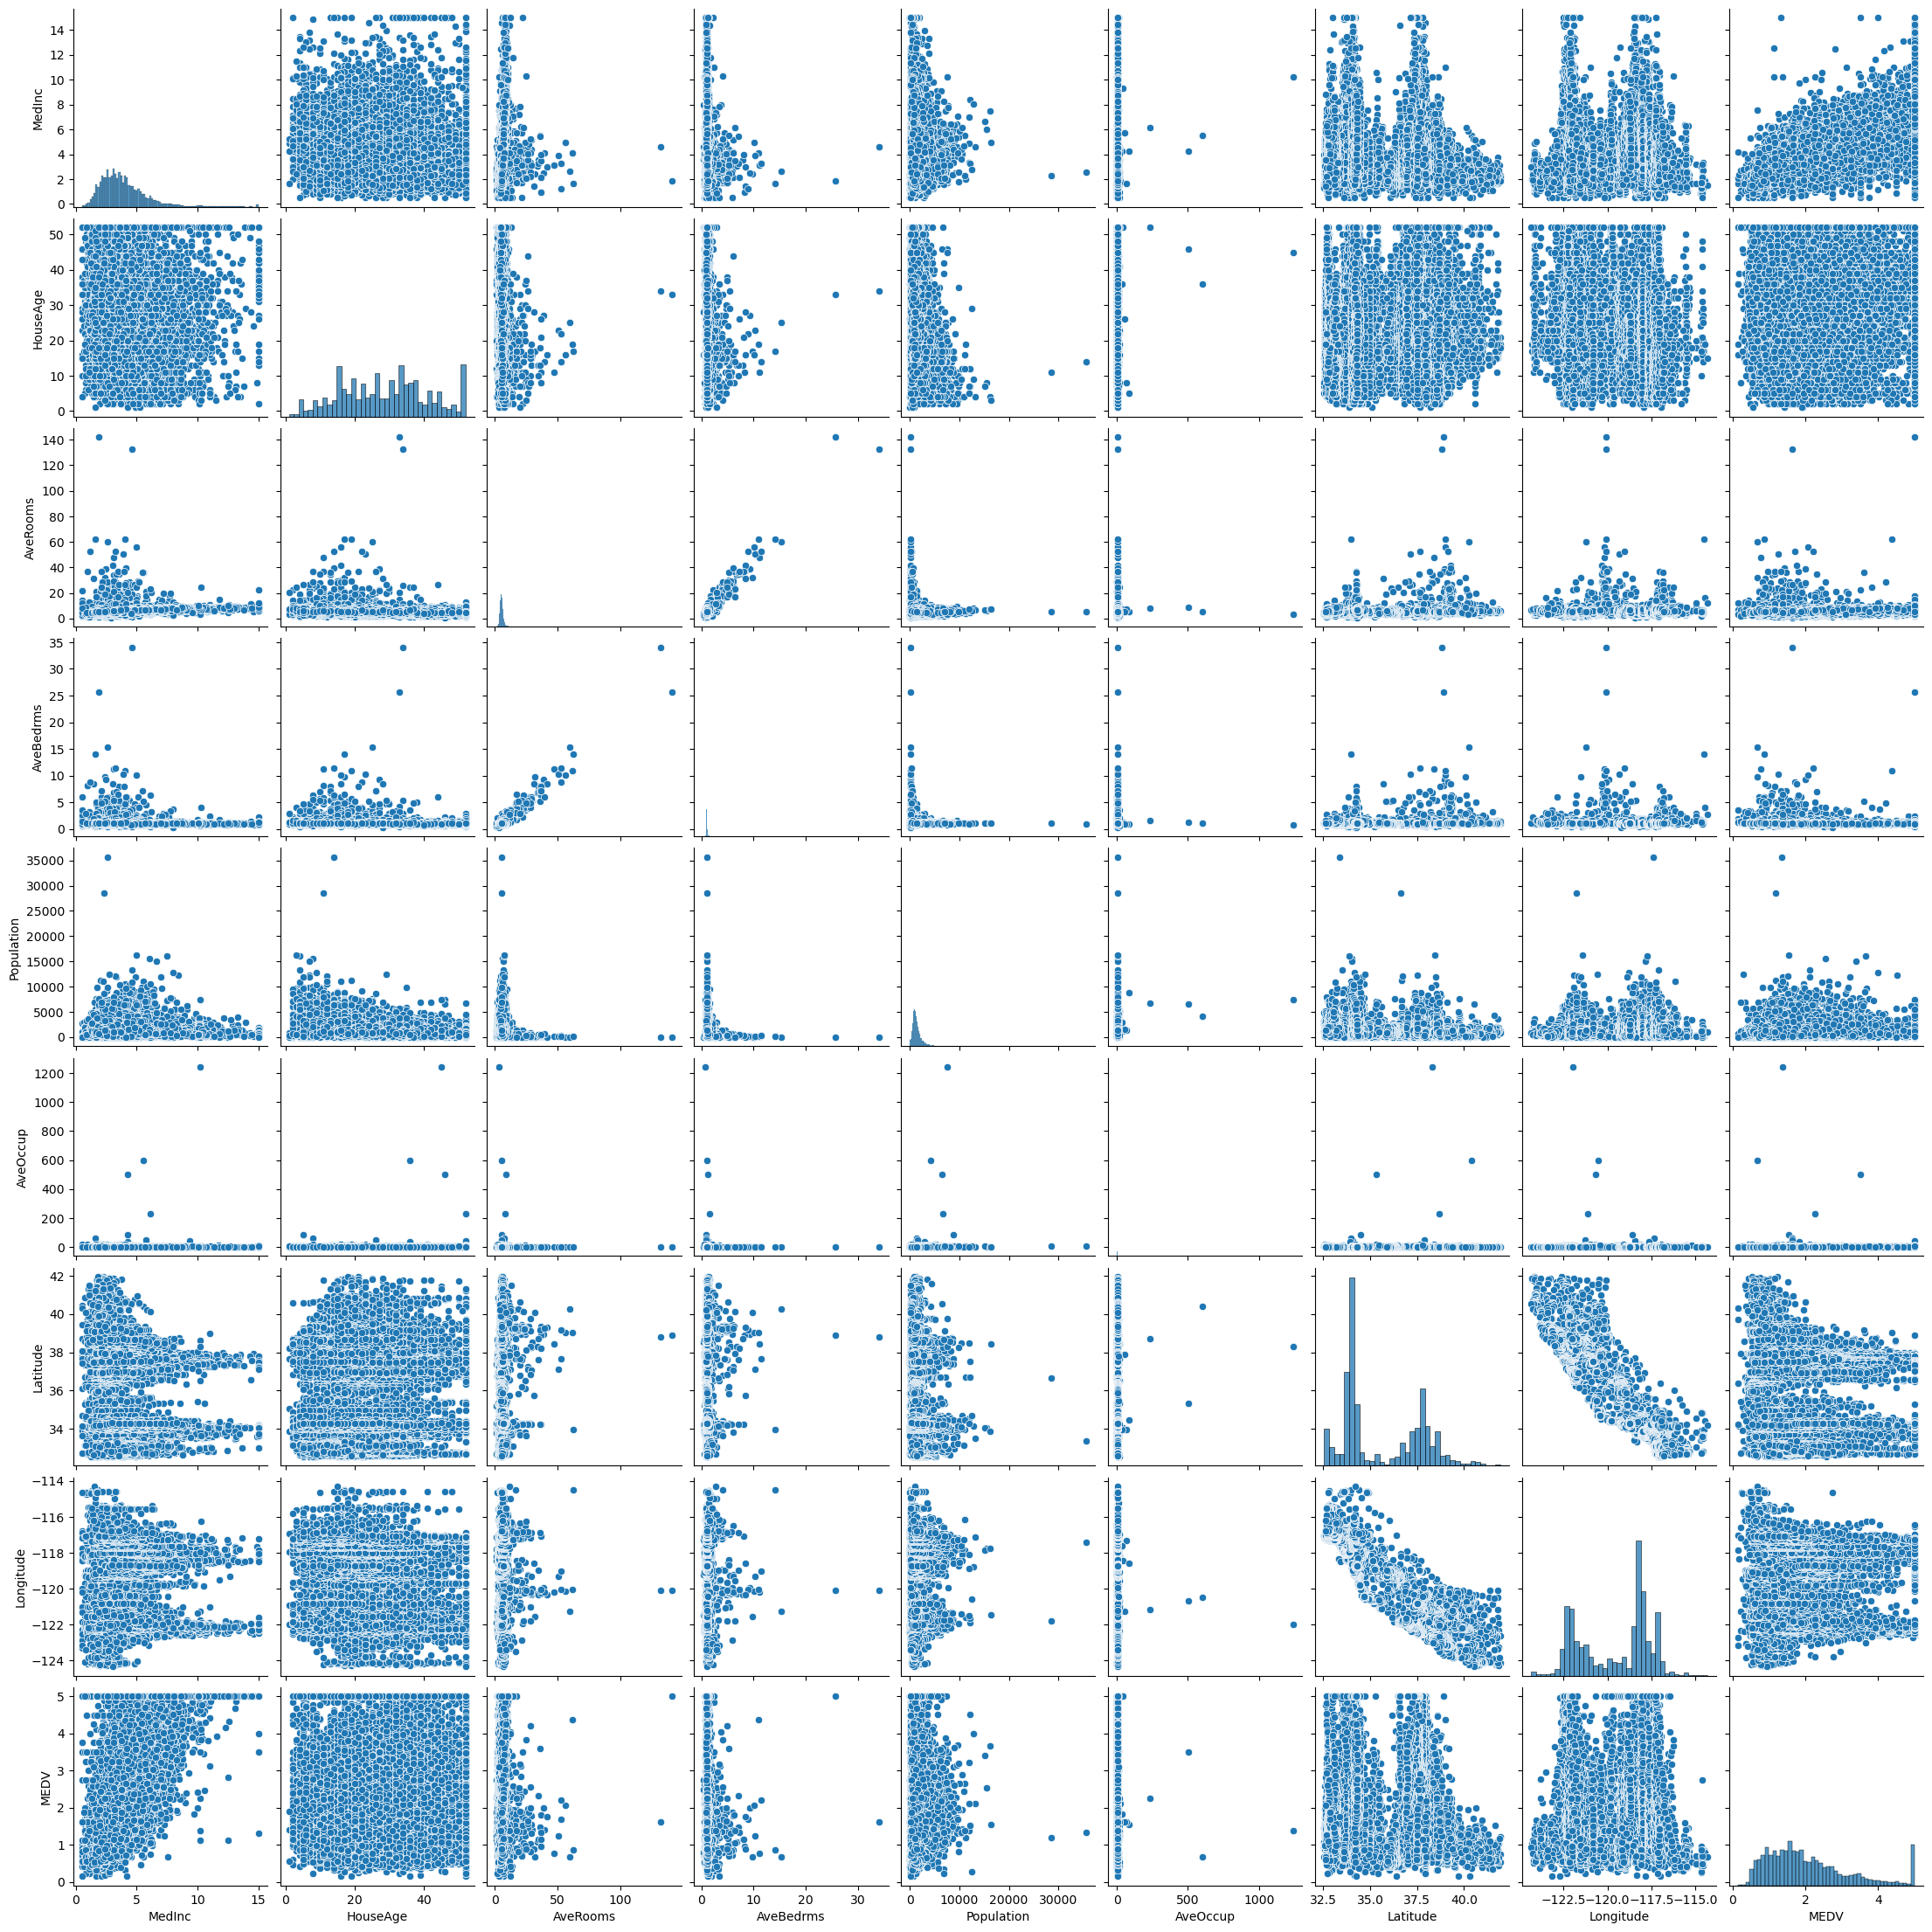

In [6]:
sns.pairplot(X_target)
plt.show()

<a id='10_1'></a>

## Ülesanne 10.1


Joonistada *Seaborn pairplot* graafikud Iiriste andmestiku jaoks ( [sklearn.datasets.load_iris()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)).

Milliste atribuutide vahel paistab olevat tugevaim korrelatsioon?
Millised atribuudid paistavad vastavat kõige paremini normaaljaotusele?

Koostada *Seaborn pairplot* graafikud ka veinide andmestiku jaoks  ([sklearn.datasets.load_wine()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)). Kuivõrd loetav on selline $13 \times 13$ graafikute tabel? Kummas andmestikus (iirised või veinid) on korrelatsioonid atribuutide vahel tugevamad?

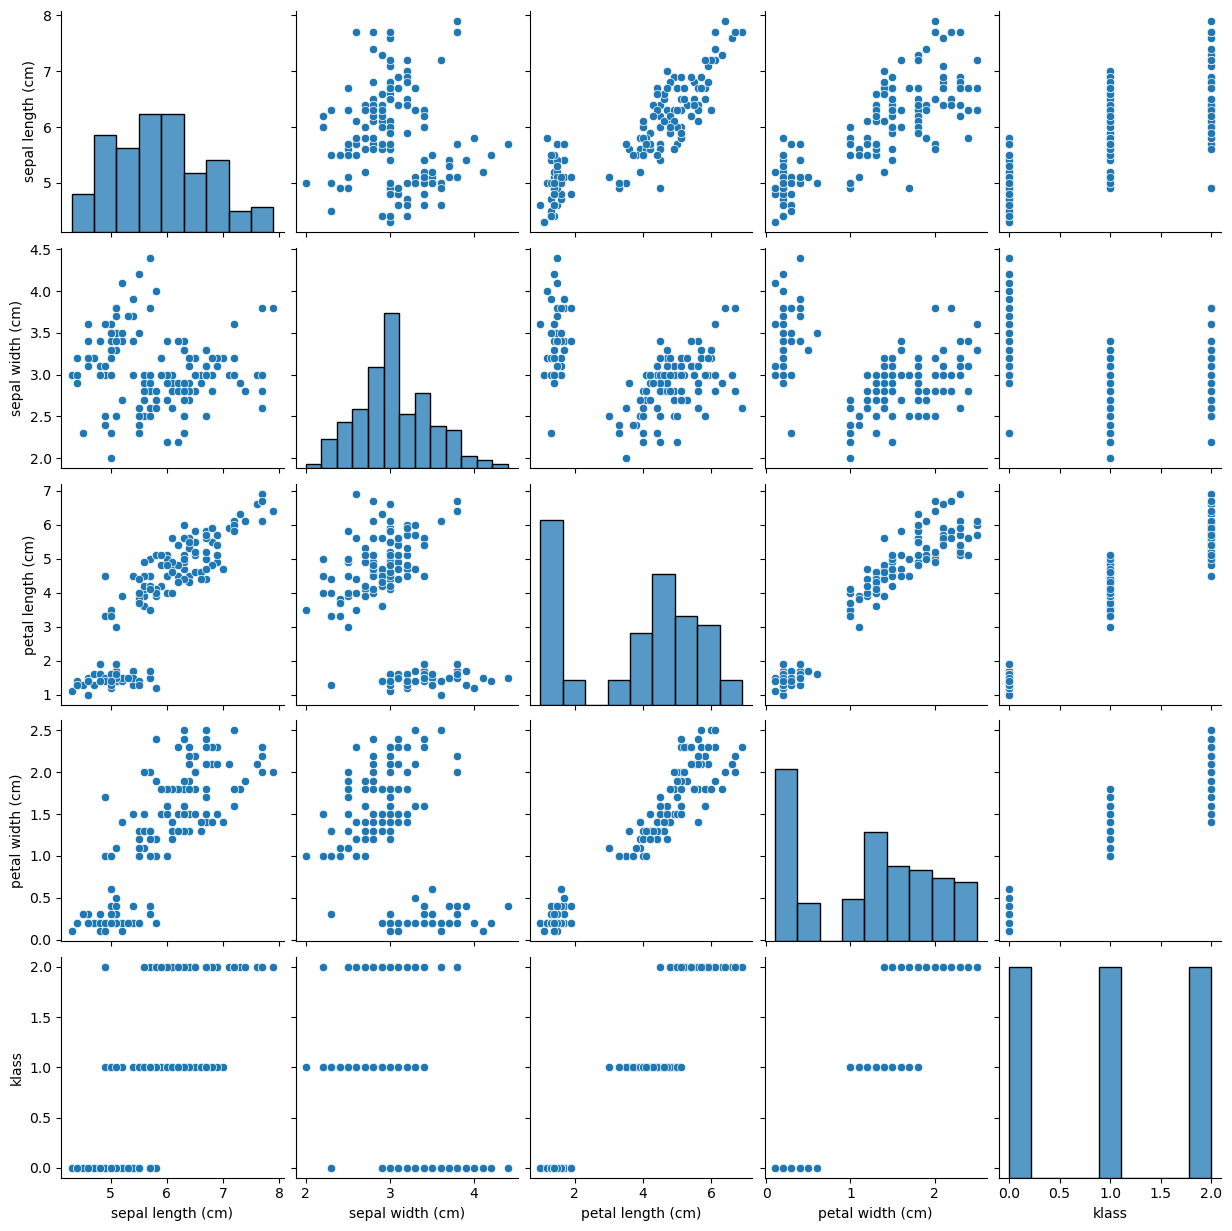

In [7]:
from sklearn import datasets
import numpy as np
import seaborn as sns

iris = datasets.load_iris()
iiris_X = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_y = iris.target
iris_X_target = iiris_X.assign(klass=iris_y)
sns.pairplot(iris_X_target)
plt.show()

# Tugevaim korrelatsioon on sepal length ja petal length vahel, petal length ja petal width, ja ka sepal length ja petal width
# Kõige paremini vastavad normaaljaotusele sepal length ja sepal width


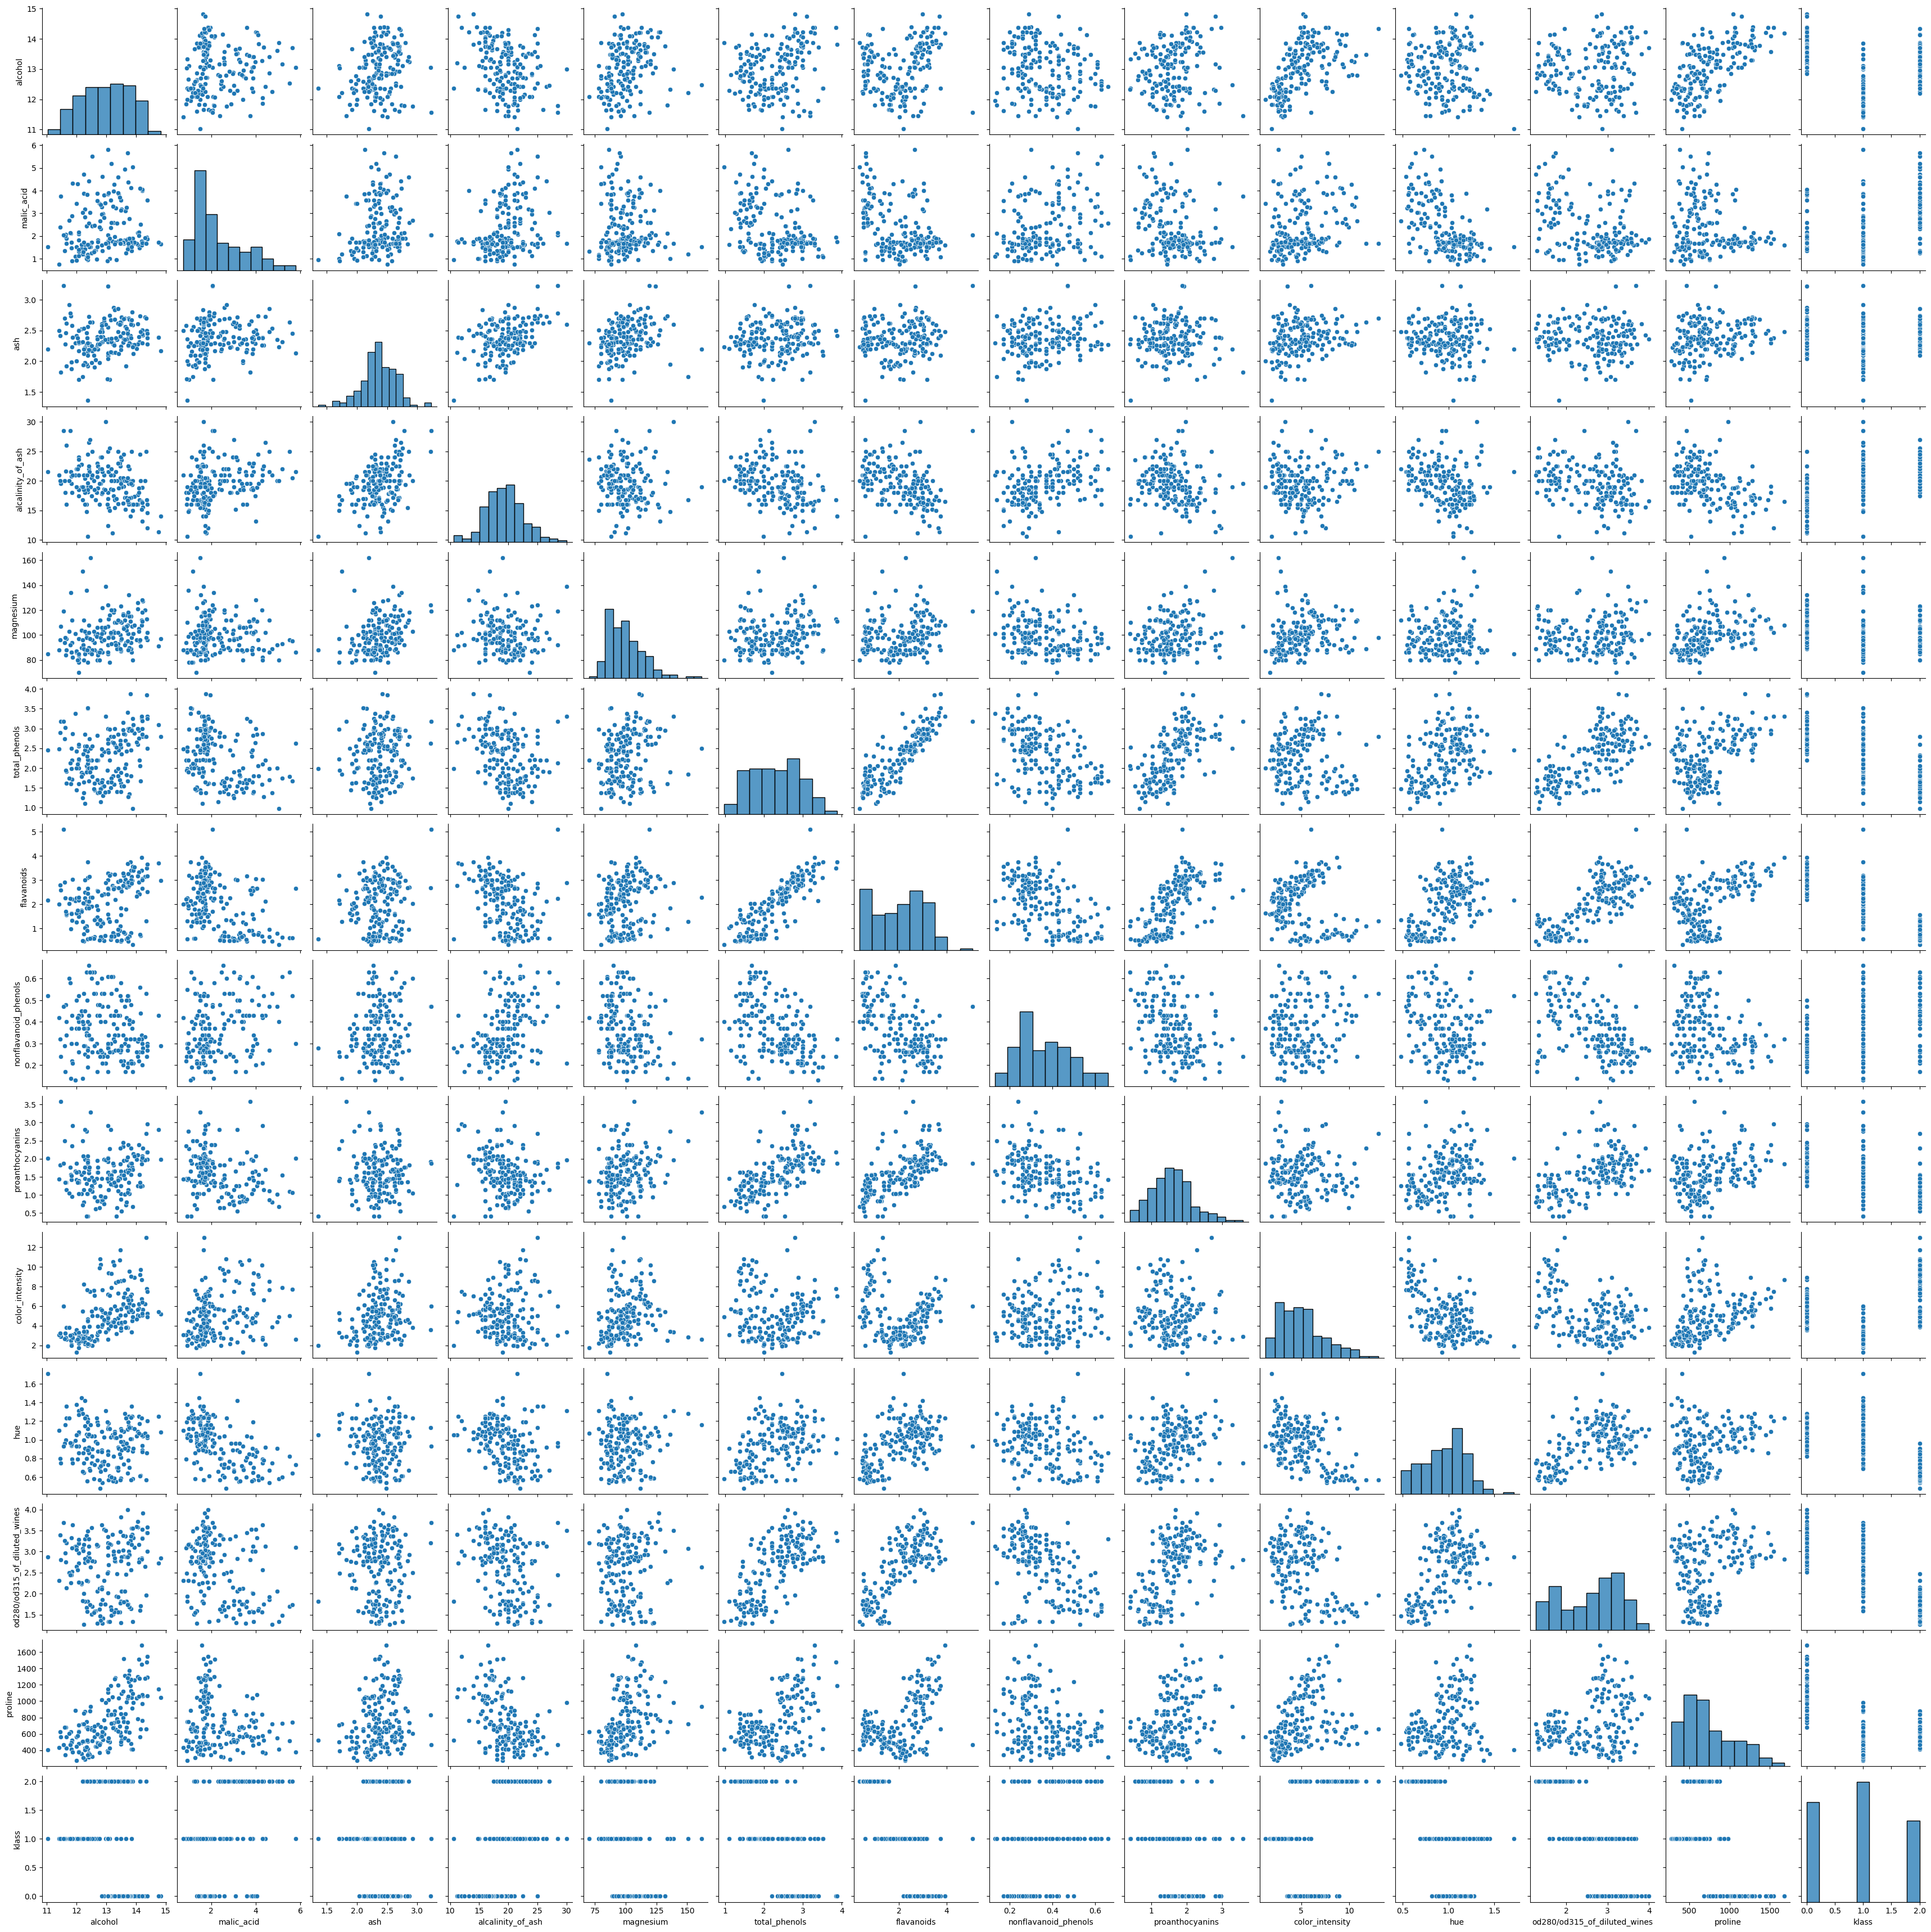

In [8]:
wine = datasets.load_wine()
wine_X = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_y = wine.target
wine_X_target = wine_X.assign(klass=wine_y)
sns.pairplot(wine_X_target)
plt.show()

# Korrelatsioon: flavanoids ja total phenoles 
# Normaaljaotus: alcohol, alcalinity of ash, total phenoles... 
# Selline 13x13 tabel ei ole kõige paremini loetav
# Iiriste andmestikus on korrelatsioonid atribuutide vahel tugevamad

In [9]:
# print(wine.DESCR)

<a id='kor'></a>

## Korrelatsioonimaatriks

Korrelatsioon, Pearsoni r

$$ r = \frac{\sigma_{xy}}{\sigma_x \sigma_y} = 
       \frac{\sum_{i=1}^n [(x_i - \mu_x)(y_i - \mu_y)]}
       {\sqrt{\sum_{i=1}^n (x_i - \mu_x)^2}{\sqrt{\sum_{i=1}^n (y_i - \mu_y)^2 }}}$$

* $\sigma_{xy}$ on atribuutide $x, y$ kovariatsioon
* $\sigma_x$, $\sigma_y$ on atribuutide $x, y$ standardhälbed
* $\mu_x$, $\mu_y$ on atribuutide $x, y$ keskmised
* $n$ on objektide arv
* $x_i, y_i$ on objekti $i$ atribuutide $x, y$ väärtused.

Standardiseeritud andmestiku jaoks, kus $\sigma_x$, $\sigma_y$ on 1 ja $\mu_x$, $\mu_y$ on 0 lihtsustub see avaldis järgnevalt:

$$ r = \sum_{i=1}^n x_i y_i $$

Joonistame värvilised korrelatsioonimaatriksid loomaaia ja majade andmestikele.

In [10]:
import pandas as pd
zoo_df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data",
                    index_col=0,
                    names=["hair", "feathers","eggs", "milk","airborne","aquatic", "predator", "toothed","backbone", "breathes", "venomous", "fins", "legs", "size", "domestic", "catsize", "type"])

In [11]:
zoo_df.pop("type")
zoo_df.corr()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,size,domestic,catsize
hair,1.000000,-0.427851,-0.817382,0.878503,-0.198431,-0.473554,-0.154769,0.492531,0.191681,0.441149,-0.104245,-0.280313,0.394009,0.048973,0.207208,0.455020
feathers,-0.427851,1.000000,0.419248,-0.410761,0.656553,-0.058552,-0.104430,-0.613631,0.231403,0.254588,-0.145739,-0.223541,-0.206686,0.292569,0.031586,-0.135934
eggs,-0.817382,0.419248,1.000000,-0.938848,0.376646,0.376244,0.011605,-0.642150,-0.340420,-0.382777,0.098689,0.164796,-0.224918,-0.221090,-0.155610,-0.514650
milk,0.878503,-0.410761,-0.938848,1.000000,-0.366765,-0.362613,-0.029721,0.628168,0.384958,0.423527,-0.242449,-0.156328,0.214196,0.210026,0.163928,0.574906
airborne,-0.198431,0.656553,0.376646,-0.366765,1.000000,-0.172638,-0.295181,-0.594311,-0.104718,0.286039,0.008528,-0.251157,0.043712,0.009482,0.063274,-0.349768
aquatic,-0.473554,-0.058552,0.376244,-0.362613,-0.172638,1.000000,0.375978,0.053150,0.022463,-0.637506,0.087915,0.604492,-0.360638,-0.034642,-0.224308,-0.111866
predator,-0.154769,-0.104430,0.011605,-0.029721,-0.295181,0.375978,1.000000,0.129452,0.051022,-0.262931,0.115391,0.190302,-0.099723,0.018947,-0.309794,0.144790
toothed,0.492531,-0.613631,-0.642150,0.628168,-0.594311,0.053150,0.129452,1.000000,0.575085,-0.065690,-0.062344,0.364292,-0.193476,0.310368,0.069430,0.344010
backbone,0.191681,0.231403,-0.340420,0.384958,-0.104718,0.022463,0.051022,0.575085,1.000000,0.207666,-0.246611,0.209499,-0.432856,0.731762,0.101733,0.356976
breathes,0.441149,0.254588,-0.382777,0.423527,0.286039,-0.637506,-0.262931,-0.065690,0.207666,1.000000,-0.120752,-0.617219,0.369868,0.088952,0.124068,0.204125


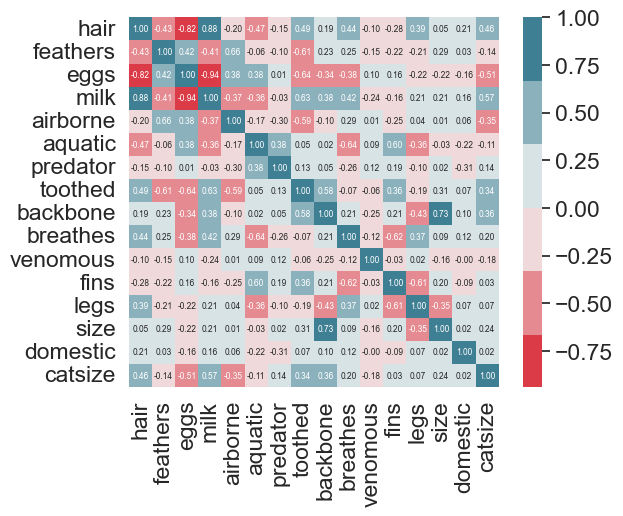

In [12]:
cm_z = zoo_df.corr()
sns.set(font_scale=1.5)
hm = sns.heatmap(cm_z, cbar=True, annot=True, square=True, fmt='.2f',
                 annot_kws={'size': 6}, yticklabels=zoo_df.columns,
                 xticklabels=zoo_df.columns, 
                 cmap=sns.diverging_palette(10, 220, sep=20),
                 center=0.0)
plt.show()

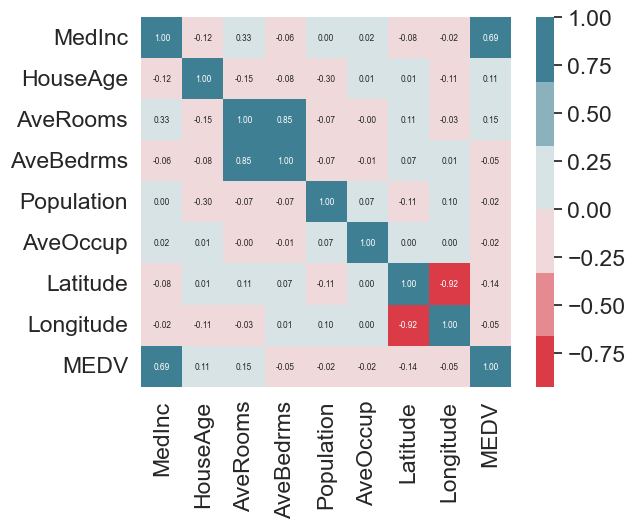

In [13]:
cm = np.corrcoef(X_target.T)
sns.set(font_scale=1.5)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f',
                 annot_kws={'size': 6}, yticklabels=X_target.columns,
                 xticklabels=X_target.columns, 
                 cmap=sns.diverging_palette(10, 220, sep=20),
                 center=0.0)
plt.show()

In [14]:
pd.DataFrame(cm)

,0,1,2,3,4,5,6,7,8
0,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
1,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
2,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
3,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
4,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
5,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
6,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
7,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
8,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


*Clustermap* (klasterdamine on tulevase loengu teema) järjestab read ja veerud nõnda ümber, et sarnaste väärtustega ehk lähedased veerud on lähestikku.

Organiseerime nõnda ümber oma eelnevad korrelatsioonimaatriksid.

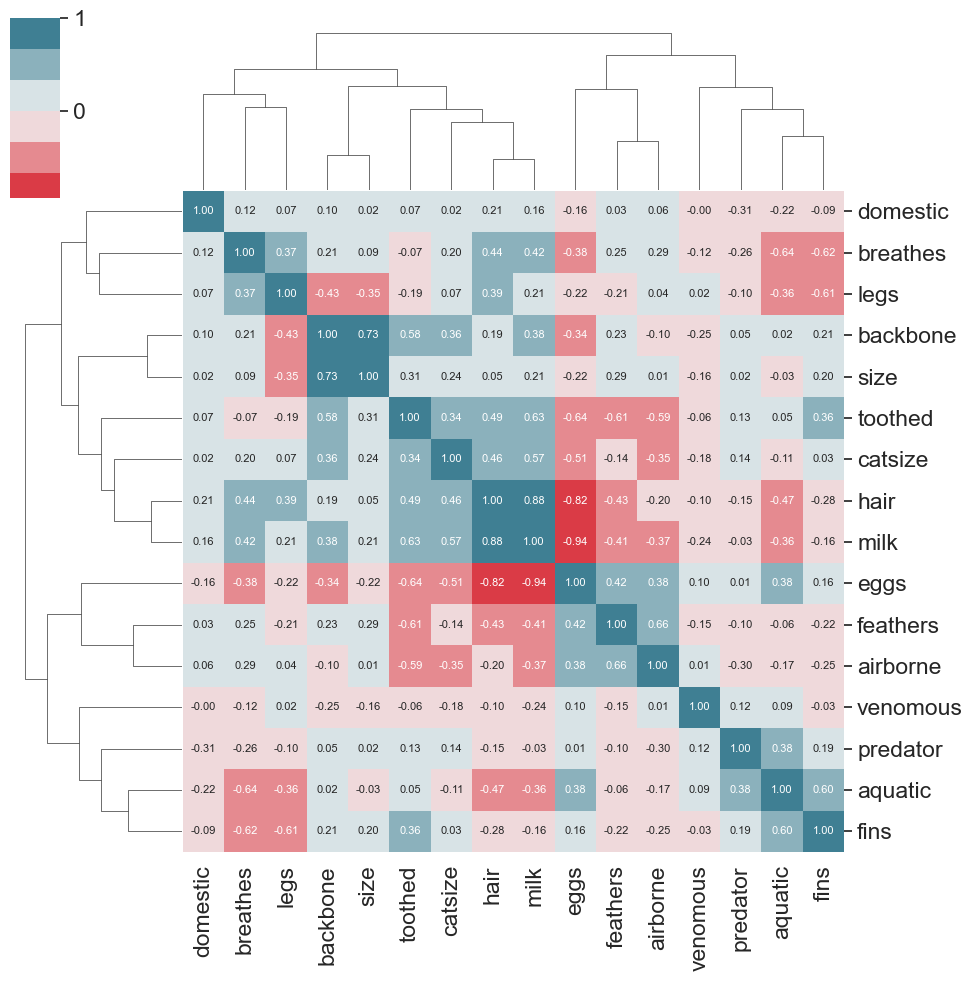

In [15]:
km = sns.clustermap(cm_z, cbar=True, annot=True,fmt='.2f',
                    annot_kws={'size': 8}, yticklabels=zoo_df.columns,
                    xticklabels=zoo_df.columns, 
                    cmap=sns.diverging_palette(10, 220, sep=20),
                    center=0.0)
plt.show()

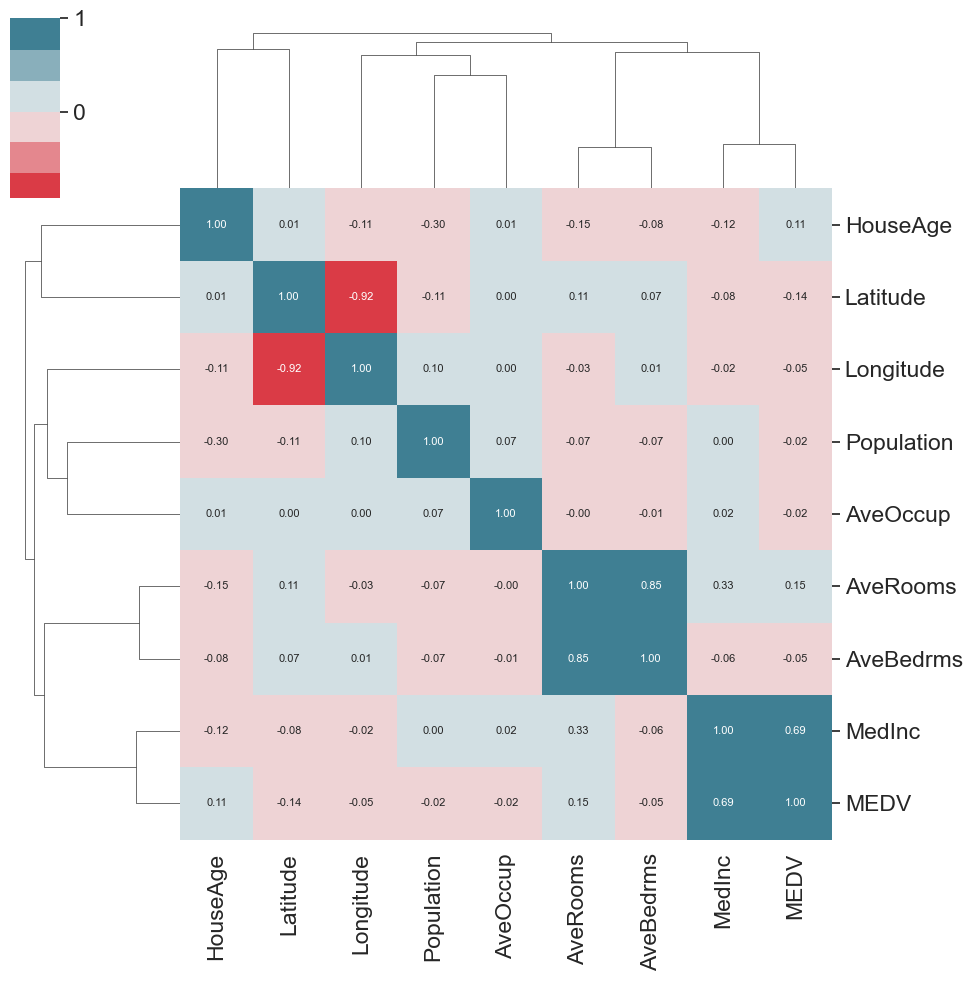

In [16]:
km = sns.clustermap(cm, cbar=True, annot=True,fmt='.2f',
                    annot_kws={'size': 8}, yticklabels=X_target.columns,
                    xticklabels=X_target.columns, 
                    cmap=sns.diverging_palette(10, 220, sep=10),
                    center=0.0)
plt.show()

<a id='lin'></a>

## Lineaarregressioon

Pideva muutuja ennustamine erineb klassi ennustamisest, kuna siin ennustame reaalarvu. Ennustus ei ole siin 100% pihta või mööda vaid oluline on ennustusvea suurus. Esimese meetodina vaatleme lineaarregressiooni.

Lineaarregresiooni eesmärgiks on luua atribuutide $x_i$ abil väärtust $y$ ennustav mudel, st leida kaalud $w_i$ valemile

$$ y = \sum_{i=0}^m w_i x_i $$

Vähimruutude meetod leiab kaalud $w_i$ minimeerides hinnafunktsiooni

$$ J(w) = \sum_{i=1}^n (y_i - \hat{y_i})^2 $$,

kus $n$ on objektide arv, $y_i$ on tegelik väärtus ja $\hat{y_i}$ on ennustatud väärtus.

Scikit-learnis on selleks klass [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).


In [17]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

#slr = LinearRegression()
slr = Pipeline([('norm', StandardScaler()), 
                ('lr', LinearRegression())])
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, 
                                                    random_state=1)
slr.fit(X_train, y_train)

Pipeline(steps=[('norm', StandardScaler()), ('lr', LinearRegression())])

In [19]:
for col_name, x_i in zip(X.columns, slr.named_steps['lr'].coef_):
    print(col_name + "\t", round(x_i, 4))

MedInc	 0.8296
HouseAge	 0.1219
AveRooms	 -0.2737
AveBedrms	 0.3206
Population	 -0.0041
AveOccup	 -0.04
Latitude	 -0.9103
Longitude	 -0.8845


<a id='r2'></a>

## Determinatsioonikordaja R2 mudeli hindamiseks

`LinearRegression.score()` tagastab determinatsioonikordaja $R^2$, mis mõõdab kui suurt osa ennustatava muutuja varieeruvusest regressioonimudel seletab:

 $$R^2  = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y_i})^2}
                   {\sum_{i=1}^n (y_i - \mu_y)^2} $$
                   
Parim võimalik skoor $R^2 = 1.0$ on mudelil siis ja ainult siis kui ennustus on alati täpne st $\hat{y_i} = y_i$ iga $i$ jaoks. Skoor  $R^2 = 0.0$ on mudelil, mis ennustab alati ennustatava muutuja keskmist $\mu_y$,  st $\hat{y_i} = \mu_y$ iga $i$ jaoks ($\sum_{i=1}^n (y_i - \mu_y)^2$ on ennustatava muutuja $y$ dispersioon). Veel halvem mudel võib omada negatiivset skoori. Seega erineb $R^2$ mõõdikutest, nagu täpsus, mis jäävad vahemikku 0...1. Mõõdik $R^2$ jääb vahemikku $-\infty ... 1$, kuna reaalarvu ennustamise veal pole alumist piiri.


Täisarvude ennustamise hindamiseks on kasutusel nii  $R^2$ kui ka klassifitseerimise mõõdikud (täpsus, F1). $R^2$ ei arvesta täisarvude diskreetsust, klassifitseerimise mõõdikud nende järjestatust.

In [20]:
scores = cross_val_score(estimator=slr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))
print('Keskmine R2 täpsus treeningandmetel: %.3f' % slr.score(X_train, y_train))
print('Keskmine R2 täpsus testandmetel: %.3f' % slr.score(X_test, y_test))

CV keskmine R2 täpsus: 0.604 +/- 0.026
Keskmine R2 täpsus treeningandmetel: 0.608
Keskmine R2 täpsus testandmetel: 0.597


<a id='poly'></a>

## Polünomiaalregressioon

Polünomiaalregressiooni mudelis võivad muutujad $x_i$ olla ühest erinevas astmes või omavahel läbi korrutatud.

Ühe muutuja jaoks, kui polünomiaalregressiooni aste on $d$:

$$ y = w_0 + w_1 x + w_2 x^2 + ... + w_dx^d $$

Mitme muutuja korral käiakse läbi ka kõikvõimalikud muutujate kombinatsioonid, nagu näiteks kahe muutuja $x_1, x_2$ ja astme $d=2$ korral:

$$ y = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_2^2 +
w_5 x_1 x_2 $$

Scikit learnis teisendab andmed sobivale kujule klass
[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html), misjärel tuleb rakendada Lineaarset regressiooni. Sobiv kuju eelmises näites: tekitame atribuudid $1, x_1, x_2, x_1^2, x_2^2, x_1 x_2$.


In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline

iris = load_iris()
Xi = pd.DataFrame(iris.data[:, :3], columns=iris.feature_names[:3])
yi = iris.data[:, 3]
Xi.head()

,sepal length (cm),sepal width (cm),petal length (cm)
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


In [22]:
p_t = PolynomialFeatures(degree=2)
print(Xi.shape)
p_t.fit_transform(Xi).shape

(150, 3)


(150, 10)

Minnes iiriste andmestikus astmeni 2 tekib $x_1, x_2, x_3$ kombinatsioonidest kümme atribuuti:
$1, x_1, x_2, x_3, x_1^2, x_1 x_2, x_1 x_3, x_2^2, x_2 x_3, x_3^2$

In [23]:
print("x_1 aste, x_2 aste, x_3 aste")
print(p_t.powers_)

x_1 aste, x_2 aste, x_3 aste
[[0 0 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [2 0 0]
 [1 1 0]
 [1 0 1]
 [0 2 0]
 [0 1 1]
 [0 0 2]]


In [24]:
p_t.fit_transform(Xi)[:5]

array([[ 1.  ,  5.1 ,  3.5 ,  1.4 , 26.01, 17.85,  7.14, 12.25,  4.9 ,
         1.96],
       [ 1.  ,  4.9 ,  3.  ,  1.4 , 24.01, 14.7 ,  6.86,  9.  ,  4.2 ,
         1.96],
       [ 1.  ,  4.7 ,  3.2 ,  1.3 , 22.09, 15.04,  6.11, 10.24,  4.16,
         1.69],
       [ 1.  ,  4.6 ,  3.1 ,  1.5 , 21.16, 14.26,  6.9 ,  9.61,  4.65,
         2.25],
       [ 1.  ,  5.  ,  3.6 ,  1.4 , 25.  , 18.  ,  7.  , 12.96,  5.04,
         1.96]])

In [25]:
plr = Pipeline(steps = [('sc', StandardScaler()),
                        ('pf', PolynomialFeatures(degree=2)),
                        ('lr', LinearRegression())])
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X, y,test_size=0.2, 
                                                    random_state=1)
plr.fit(Xi_train, yi_train)
scores = cross_val_score(estimator=plr,
                         X=Xi_train,
                         y=yi_train,
                         cv=10,
                         n_jobs=1)
print('CV keskmine täpsus R2: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))
print('Täpsus R2 treeningandmetel: %.3f' % plr.score(Xi_train, yi_train) )
print('Täpsus R2 testandmetel: %.3f' % plr.score(Xi_test, yi_test))

CV keskmine täpsus R2: 0.201 +/- 0.723
Täpsus R2 treeningandmetel: 0.686
Täpsus R2 testandmetel: 0.665


## Polünomiaalregressiooni astme validatsioonikõver 

Joonistame parameetri *degree* validatsioonikõvera, demonstreerimaks ülesobitamist (*overfitting*), mis toimub *degree* suurte väärtuste korral.

In [26]:
from sklearn.model_selection import validation_curve

param_range = range(1, 5)
train_scores, test_scores = validation_curve(
                estimator=plr, 
                X=Xi_train, 
                y=yi_train, 
                param_name='pf__degree', #formaat: KonveieriKomponendiNimi__ParameetriNimi
                param_range=param_range,
                cv=10)


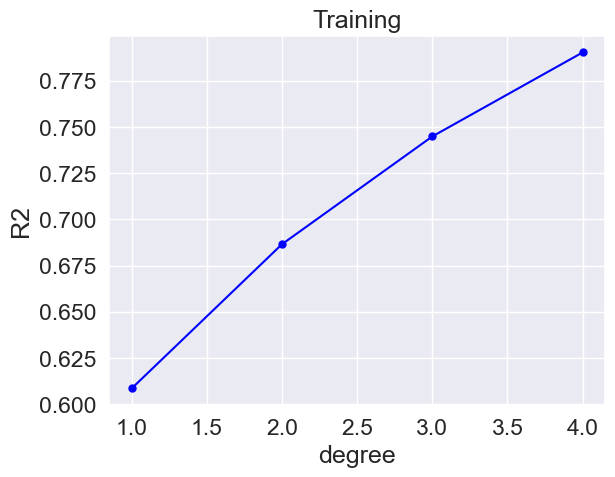

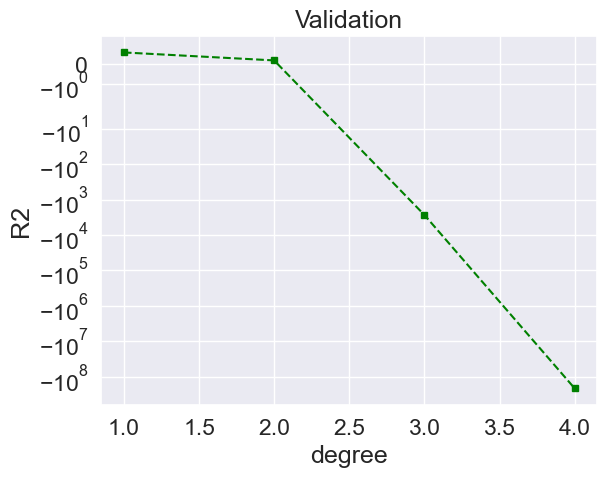

In [27]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


plt.plot(param_range, train_mean, 
         color='blue', marker='o', 
         markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Training")
plt.show()

plt.plot(param_range, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Validation")
plt.yscale('symlog')
plt.show()




Näeme, et suuremate *degree* väärtuste korral on naiivne R2 skoor treeningandmetel ideaalne >0.85, aga korrektsel kontrollil testandmetega äärmuslikult negatiivne. 

Järgnevalt koostame lihtsa lineaarregressiooni mudeli.

In [28]:
lr = Pipeline(steps=[('sc', StandardScaler()),
                     ('lr', LinearRegression())])
lr.fit(Xi_train, yi_train)
scores = cross_val_score(estimator=lr,
                         X=Xi_train,
                         y=yi_train,
                         cv=10,
                         n_jobs=1)
print('CV keskmine täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))
print('Täpsus R2 treeningandmetel: %.3f' % lr.score(Xi_train, yi_train) )
print('Täpsus R2 testandmetel: %.3f' % lr.score(Xi_test, yi_test))

CV keskmine täpsus: 0.604 +/- 0.026
Täpsus R2 treeningandmetel: 0.608
Täpsus R2 testandmetel: 0.597


Katsume nüüd ennustada piirkonna kinnisvara mediaanväärtust ühe atribuudi MedInc alusel (visualiseerimise näitena).

In [29]:
X_medinc = X.MedInc.values.reshape(-1, 1)

lr.fit(X_medinc, y)
lr.score(X_medinc, y)

0.47344749180719903

In [30]:
scores = cross_val_score(estimator=lr,
                         X=X_medinc,
                         y=y,
                         cv=10,
                         n_jobs=1)
print('Lin. reg. CV keskmine täpsus R2: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

Lin. reg. CV keskmine täpsus R2: 0.348 +/- 0.180


In [31]:
# Vaatame pairplot-i pealt, milline atribuut on maja mediaanväärtusega
# mittelineaarses seoses (kõverjoon). 
# Täpsushinnangu leidmine ainult treeningandmetelt on üldjuhul ebasoovitav.


plr.fit(X_medinc, y)
plr.score(X_medinc, y)

0.47802403432955454

In [32]:
scores = cross_val_score(estimator=plr,
                         X=X_medinc,
                         y=y,
                         cv=10,
                         n_jobs=1)
print('Pol. reg. CV keskmine täpsus R2: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

Pol. reg. CV keskmine täpsus R2: 0.349 +/- 0.185


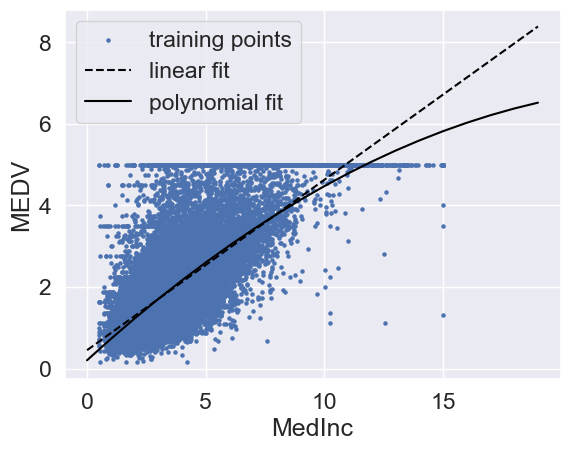

In [33]:
plt.scatter(X_medinc, y, label="training points", s=5)
X_fit = np.arange(0, 20, 1).reshape(-1, 1)
y_lin_fit = lr.predict(X_fit)
plt.plot(X_fit, y_lin_fit, label='linear fit', linestyle='--', color='black')
y_pol_fit = plr.predict(X_fit)
plt.plot(X_fit, y_pol_fit, label='polynomial fit', color='black')
plt.legend()
plt.xlabel('MedInc')
plt.ylabel('MEDV')
plt.show()

<a id='puu'></a>

## Otsustuspuu regressioon

Otsustuspuu ennustuseks objektile on vastavas otsustuspuu lehes olevate treeningandmete keskväärtus. Juhuslikus metsas keskmistatakse ennustused veelkord üle metsa puude.


[DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)


[RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)


Sellised meetodid on sobivad ka täisarvuliste väärtuste ennustamiseks.


In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_medinc, y)
print("Tree score: ", tree.score(X_medinc, y))

forest = RandomForestRegressor(n_estimators=100, criterion='friedman_mse')
forest.fit(X_medinc, y)
print("Forest score: ", forest.score(X_medinc, y))

Tree score:  0.48240295133703315
Forest score:  0.7630666588942125


In [35]:
scores = cross_val_score(estimator=tree,
                         X=X_medinc,
                         y=y,
                         cv=5,
                         n_jobs=1)
print('Otsustuspuu CV keskmine täpsus R2: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

Otsustuspuu CV keskmine täpsus R2: 0.423 +/- 0.086


In [36]:
scores = cross_val_score(estimator=forest,
                         X=X_medinc,
                         y=y,
                         cv=5,
                         n_jobs=1)
print('Juhusliku metsa CV keskmine täpsus R2: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

Juhusliku metsa CV keskmine täpsus R2: 0.242 +/- 0.094


NB! Võrrelge juhusliku metsa tulemust treeningandmetel ja ristkontrolliga. Siin on tegemist ülekohandamisega.

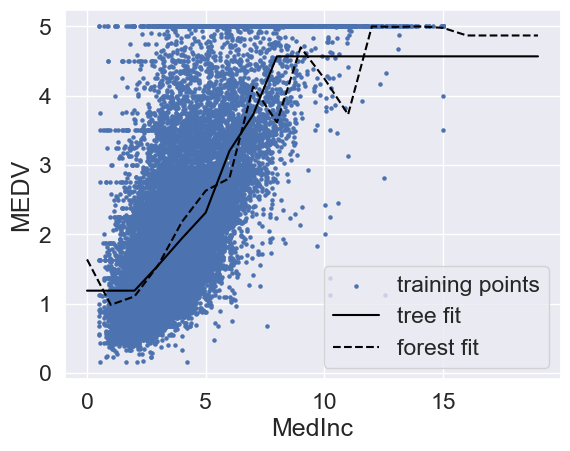

In [37]:
plt.scatter(X_medinc, y, label="training points", s=5)
X_fit = np.arange(0, 20, 1).reshape(-1, 1)
y_tree_fit = tree.predict(X_fit)
y_forest_fit = forest.predict(X_fit)
plt.plot(X_fit, y_tree_fit, label='tree fit', color='black')
plt.plot(X_fit, y_forest_fit, label='forest fit', linestyle='--', color='black')
plt.legend()
plt.xlabel('MedInc')
plt.ylabel('MEDV')
plt.show()

<a id='10_2'></a>

## Ülesanne 10.2

* Joonistage teegi `Seaborn`abil *Clustermap* järjestatud korrelatsioonimaatriks veinide andmestikule.

* Võtke veinide andmestiku atribuut *proline* teiste atribuutide põhjal ennustatavaks väärtuseks. St tõstke veerg *proline* andmestikust (*X*) välja ja omistage ennustatavate väärtustena sobivale muutujale (*target*, *y*).

* Koostage lineaarse ([LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)) ja polünomiaalse regressiooni ([LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) + [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) mudelid ja kasutage ka  [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) kui ka [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) meetodeid (ilma [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) teisenduseta). Leidke nende jaoks $R^2$ skoorid nii treening- kui testandmetel.

* Joonistage validatsioonikõverad parameetri *degree* erinevate väärtuste jaoks vahemikus 1...5  [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) + [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) polünomiaalse regressiooni mudeli jaoks.



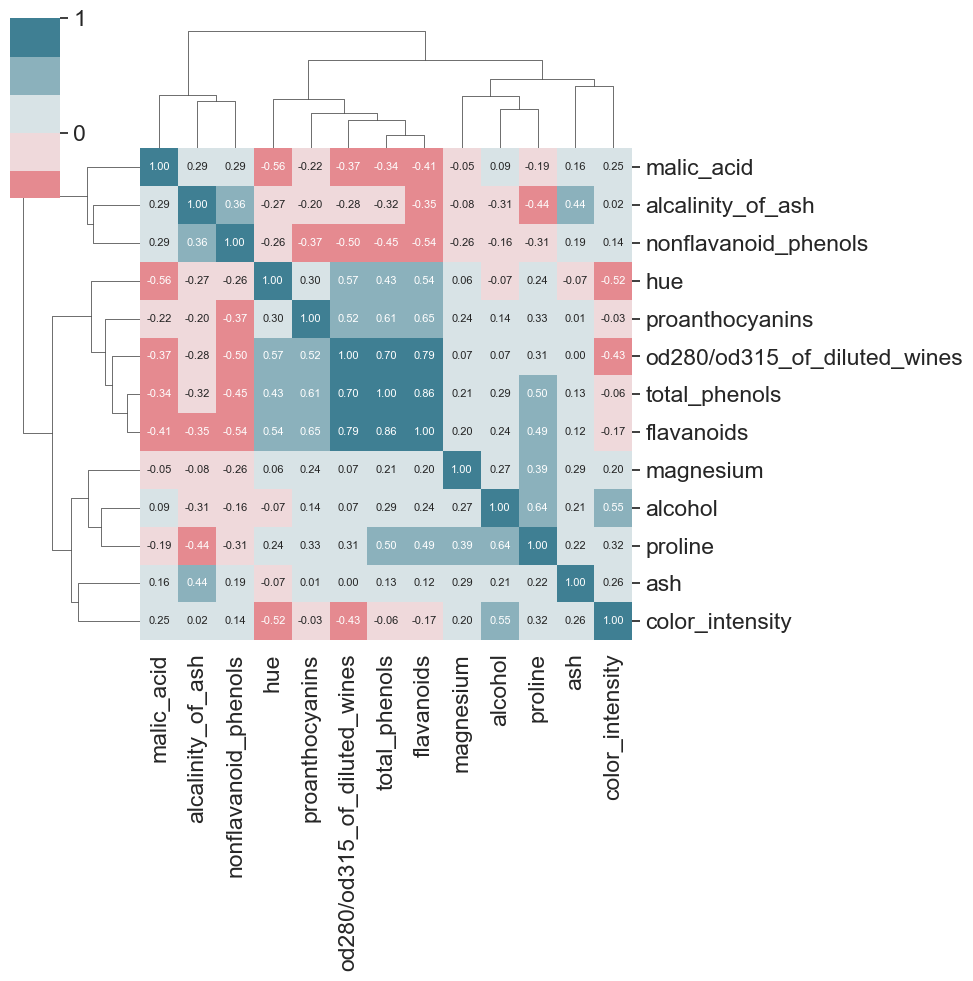

In [38]:
# Korrelatsioonimaatriks
wine_km = wine_X.corr()

# Järjestatud korr. maatriks - järjestab read ja veerud nõnda ümber, et sarnaste väärtustega ehk lähedased veerud on lähestikku.
wine_km_jarjestatud = sns.clustermap(wine_km, cbar=True, annot=True,fmt='.2f',
                    annot_kws={'size': 8}, yticklabels=wine_X.columns,
                    xticklabels=wine_X.columns, 
                    cmap=sns.diverging_palette(10, 220, sep=20),
                    center=0.0)
plt.show()

In [47]:
# võtta atribuut proline ennustatavaks väärtuseks
wine_target_proline = wine_X.pop('proline')
wine_X

,0,1,2,3,4,5,6,7,8,9,10,11
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00


In [40]:
# Koostada lineaarse ([LinearRegression] ja polünomiaalse regressiooni ([LinearRegression] + [PolynomialFeatures]) mudelid ja kasutage ka  
# [DecisionTreeRegressor] kui ka [RandomForestRegressor] meetodeid (ilma [PolynomialFeatures] teisenduseta). 
# Leidke nende jaoks R^2 skoorid nii treening- kui testandmetel.

# Jagan andmestiku treening- ja testandmeteks
X_train, X_test, y_train, y_test = train_test_split(wine_X, wine_target_proline, test_size=0.2, 
                                                    random_state=1)

# LinearRegression mudel
lr = Pipeline([('sc', StandardScaler()), 
                ('lr', LinearRegression())])

lr.fit(X_train, y_train)

scores = cross_val_score(estimator=lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('lr CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('lr täpsus R2 treeningandmetel: %.3f' % lr.score(X_train, y_train))
print('lr täpsus R2 testandmetel: %.3f \n' % lr.score(X_test, y_test))



# LinearRegression + Polünomiaalne teisendus 
plr = Pipeline([('sc', StandardScaler()), 
                ('pf', PolynomialFeatures(degree=2)),
                ('lr', LinearRegression())])

plr.fit(X_train, y_train)

scores = cross_val_score(estimator=plr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('plr CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('plr täpsus R2 treeningandmetel: %.3f' % plr.score(X_train, y_train))
print('plr täpsus R2 testandmetel: %.3f \n' % plr.score(X_test, y_test))



# DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_train, y_train)

scores = cross_val_score(estimator=tree,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('tree CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('Tree täpsus R2 treeningandmetel: %.3f' % tree.score(X_train, y_train))
print('Tree täpsus R2 testandmetel: %.3f \n' % tree.score(X_test, y_test))


# RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100, criterion='friedman_mse')
forest.fit(X_train, y_train)

scores = cross_val_score(estimator=forest,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('forest CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('Forest täpsus R2 treeningandmetel: %.3f' % forest.score(X_train, y_train))
print('Forest täpsus R2 testandmetel: %.3f' % forest.score(X_test, y_test))




lr CV keskmine R2 täpsus: 0.422 +/- 0.285
lr täpsus R2 treeningandmetel: 0.617
lr täpsus R2 testandmetel: 0.680 

plr CV keskmine R2 täpsus: -6.490 +/- 5.343
plr täpsus R2 treeningandmetel: -1.776
plr täpsus R2 testandmetel: -16.817 

tree CV keskmine R2 täpsus: 0.301 +/- 0.590
Tree täpsus R2 treeningandmetel: 0.752
Tree täpsus R2 testandmetel: 0.679 

forest CV keskmine R2 täpsus: 0.554 +/- 0.342
Forest täpsus R2 treeningandmetel: 0.954
Forest täpsus R2 testandmetel: 0.780


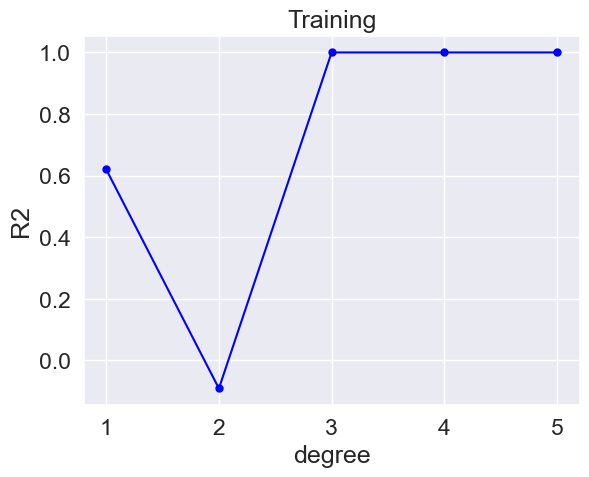

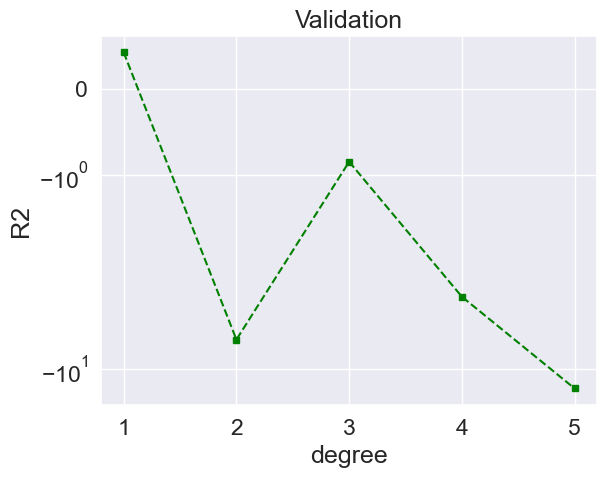

In [41]:
# Joonistage validatsioonikõverad parameetri *degree* erinevate väärtuste jaoks vahemikus 1...5  [LinearRegression] + [PolynomialFeatures] polünomiaalse regressiooni mudeli jaoks.

param_range = range(1, 6)
train_scores, test_scores = validation_curve(
                estimator=plr, 
                X=X_train, 
                y=y_train, 
                param_name='pf__degree', #formaat: KonveieriKomponendiNimi__ParameetriNimi
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


plt.plot(param_range, train_mean, 
         color='blue', marker='o', 
         markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Training")
plt.show()

plt.plot(param_range, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Validation")
plt.yscale('symlog')
plt.show()
